In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
hotels = pd.read_excel("Data/HotelCustomersDataset.xlsx")

hotels["date"] =  (pd.to_datetime("2018-12-31")
                   - pd.to_timedelta(hotels["DaysSinceCreation"], unit="D")).astype("datetime64[ns]")

In [3]:
hotels.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom,date
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,2018-08-03
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01


# Assignment 1: Plotting DataFrames

* Plot the `LodgingRevenue` and `OtherRevenue` columns in a line chart from the `monthly_revenue` DataFrame created below.  
* Make sure your x-axis is the `date` column.

In [4]:
daily_revenue = (
    hotels
    .groupby("date")
    .agg({"LodgingRevenue":"sum", "OtherRevenue":"sum"})
)

monthly_revenue = daily_revenue.resample("ME").sum()



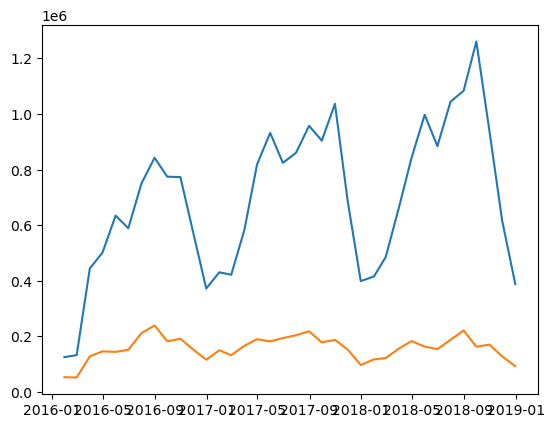

In [5]:
plt.plot(monthly_revenue);

# Assignment 2: Formatted Line Chart

Plot the monthly sum of `LodgingRevenue` and `OtherRevenue`.

Make sure to add titles and a y-axis label, remove the top and right borders, and add a legend.

Consider modifying the font sizes as well.

Thanks!

In [6]:
daily_revenue = (
    hotels
    .groupby("date")
    .agg({"LodgingRevenue":"sum", "OtherRevenue":"sum"})
)

monthly_revenue = daily_revenue.resample("ME").sum()


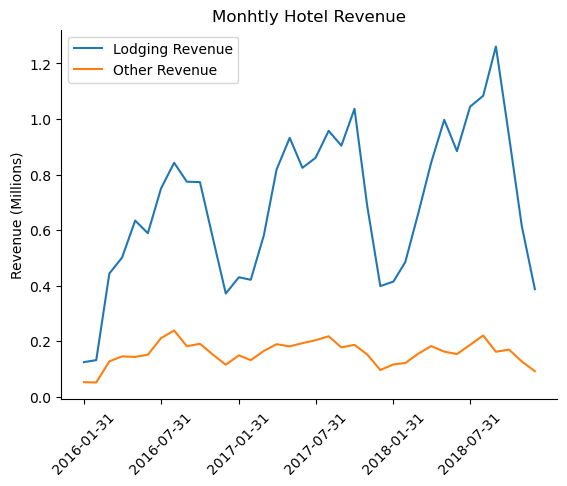

In [7]:
fig, ax = plt.subplots()

ax.plot(monthly_revenue.index, 
        monthly_revenue['LodgingRevenue'] / 1000000,
       label='Lodging Revenue')
ax.plot(monthly_revenue.index,
       monthly_revenue['OtherRevenue'] / 1000000,
       label='Other Revenue')

ax.legend(loc='upper left')
ax.set_title('Monhtly Hotel Revenue')
ax.set_ylabel('Revenue (Millions)')
ax.set_xticks(monthly_revenue.index[::6])
plt.xticks(rotation=45)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

# Assignment 2: Dual Axis Line Chart

* Plot the sum of nights booked and the sum of cancellations on a quarterly basis (resample("Q") will help). 

* Plot them in the same chart but different Y-Axes.

* Make sure to add titles and axis labels, remove scientific notation, and add a legend.

* Consider modifying the font sizes as well.

In [8]:
room_nights = hotels.groupby('date').agg({'RoomNights':'sum', 'BookingsCanceled':'sum'})

quarterly_bookings = room_nights.resample('QE').sum()

In [9]:
quarterly_bookings.head()

,RoomNights,BookingsCanceled
date,,
2016-03-31,8464,15
2016-06-30,15535,26
2016-09-30,19517,27
2016-12-31,15404,17
2017-03-31,15206,12


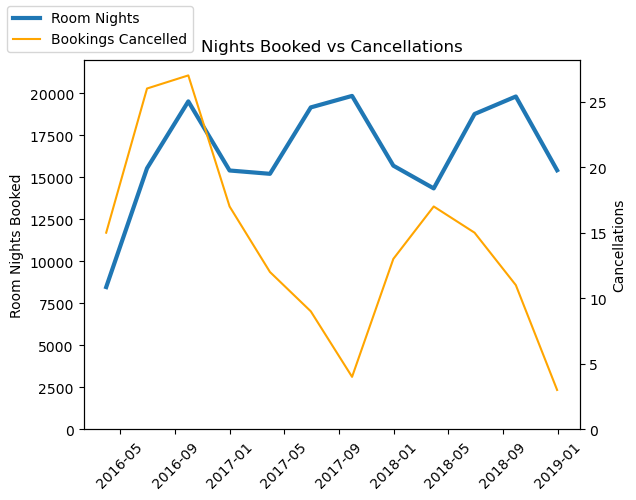

In [10]:
fig, ax = plt.subplots()

ax.plot(
    quarterly_bookings.index,
    quarterly_bookings['RoomNights'],
    label='Room Nights',
    linewidth=3
)

ax.set_title('Nights Booked vs Cancellations')
ax.set_ylabel('Room Nights Booked')
ax.set_ylim(0, 22000)
plt.xticks(rotation=45)
ax2 = ax.twinx()

ax2.plot(
    quarterly_bookings.index,
    quarterly_bookings['BookingsCanceled'],
    label='Bookings Cancelled',
    c='orange'
)

ax2.set_ylabel('Cancellations')
ax2.set_ylim(0)

fig.legend(loc='upper left')

# Assignment 3: Bar Chart

* Create a bar chart of total room nights booked by country. Limit your results to the top 10 countries.

* Then, build a horizontal bar chart of lodging revenue by country for the same countries in your room nights chart.

* As always, make sure to add labels to your chart!

In [11]:
hotels.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom,date
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,2018-08-03
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01


In [12]:
countries = (
    hotels.groupby('Nationality')
    .agg({'RoomNights': 'sum', 'LodgingRevenue': 'sum'})
    .sort_values('RoomNights', ascending=False)
    .iloc[:10]
)

In [13]:
countries

,RoomNights,LodgingRevenue
Nationality,,
FRA,31018,3809315.59
DEU,26334,3113382.55
PRT,24334,2715008.72
GBR,20822,2693123.61
ESP,10877,1475909.33
ITA,8046,1032729.72
BEL,7758,1047661.98
NLD,6619,904460.78
BRA,6535,787928.01


<BarContainer object of 10 artists>

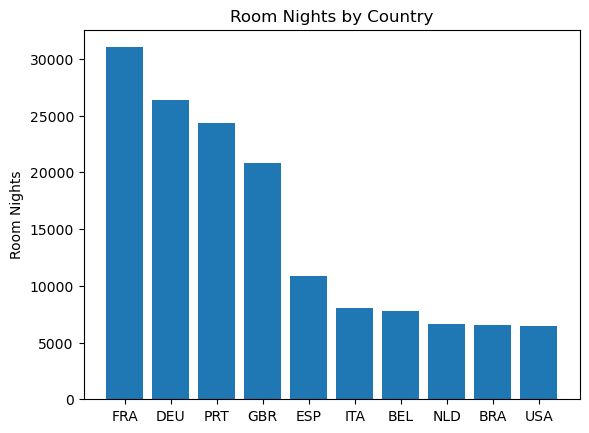

In [14]:
fig, ax = plt.subplots()

ax.set_title('Room Nights by Country')
ax.set_ylabel('Room Nights')
ax.bar(countries.index, countries['RoomNights'])

<BarContainer object of 10 artists>

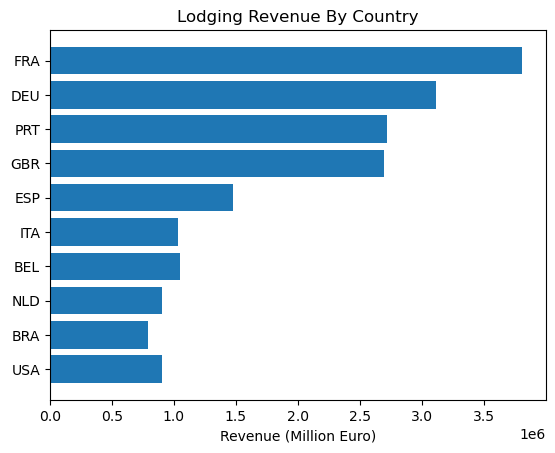

In [15]:
fig, ax = plt.subplots()
ax.set_title('Lodging Revenue By Country')
ax.set_xlabel('Revenue (Million Euro)')

ax.barh(countries.index[::-1], countries['LodgingRevenue'][::-1])

# Assignment 4: Advanced Bar Charts

* Build a grouped bar chart of our top 5 countries with LodgingRevenue and OtherRevenue as bars for each.
* Then, build a 100% bar chart stacked bar chart of LodgingRevenue and OtherRevenue. Add a reference line at 80%, which is our baseline. 

Thanks!

In [16]:
countries = ["FRA", "DEU", "PRT", "GBR", "ESP"]
country_subset = (hotels
                   .loc[hotels['Nationality'].isin(countries)]
                   .groupby('Nationality')
                    .agg({'LodgingRevenue':'sum', 'OtherRevenue':'sum'})
                    .sort_values('LodgingRevenue', ascending=False)
                   )

country_subset.head()

,LodgingRevenue,OtherRevenue
Nationality,,
FRA,3809315.59,1033166.30
DEU,3113382.55,725541.53
PRT,2715008.72,665634.58
GBR,2693123.61,591212.77
ESP,1475909.33,319840.82


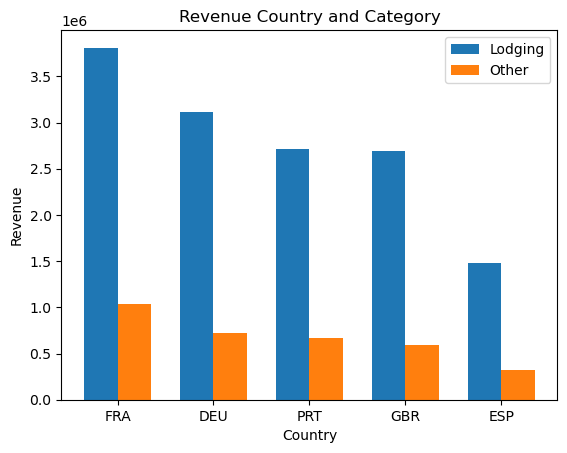

In [17]:
fig, ax = plt.subplots()

x = np.arange(0, len(countries))
width = 0.35

ax.bar(x - width/2, country_subset['LodgingRevenue'], width, label='Lodging')
ax.bar(x + width/2, country_subset['OtherRevenue'], width, label='Other')

ax.set_title('Revenue Country and Category')
ax.set_ylabel('Revenue')
ax.set_xlabel('Country')
ax.legend()

plt.xticks(range(len(countries)), countries)

plt.show()

In [18]:
country_subset_pcts = country_subset.apply(lambda x: x * 100 / sum(x), axis=1)

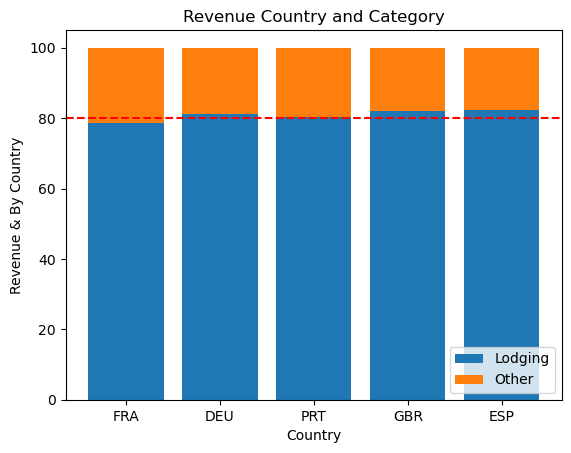

In [19]:
fig, ax = plt.subplots()

ax.bar(
    countries,
    country_subset_pcts['LodgingRevenue'],
    label='Lodging'
)

ax.bar(
    countries,
    country_subset_pcts['OtherRevenue'],
    label='Other',
    bottom=country_subset_pcts['LodgingRevenue']
)

ax.axhline(80, 0, 1, c='red', ls='--')

ax.set_title('Revenue Country and Category')
ax.set_ylabel('Revenue & By Country')
ax.set_xlabel('Country')
ax.legend(loc='lower right')

# Assignment 5: Pie Charts

* Build a pie chart of LodgingRevenue by country. Include a slice for our top 5 countries and combine the rest into an 'other' Category.
* Then, convert the pie chart into a donut chart.

In [23]:
country_pcts = hotels.groupby('Nationality').agg({'LodgingRevenue': 'sum'}).sort_values('LodgingRevenue', ascending=False)

country_pcts

,LodgingRevenue
Nationality,
FRA,3809315.59
DEU,3113382.55
PRT,2715008.72
GBR,2693123.61
ESP,1475909.33
...,...
NRU,0.00
NPL,0.00
TON,0.00


In [27]:
pie_data = (pd.concat([country_pcts.iloc[:5],
                      pd.DataFrame({'LodgingRevenue': country_pcts.iloc[5:, 0].sum()}, index=['OTH'])])).iloc[::-1]

In [28]:
pie_data

,LodgingRevenue
OTH,11170126.66
ESP,1475909.33
GBR,2693123.61
PRT,2715008.72
DEU,3113382.55
FRA,3809315.59


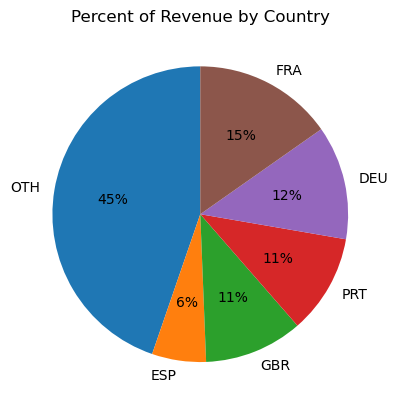

In [32]:
fig, ax = plt.subplots()

ax.pie(pie_data['LodgingRevenue'],
      startangle=90,
      labels=pie_data.index,
      autopct='%.0f%%')

ax.set_title('Percent of Revenue by Country')

plt.show()

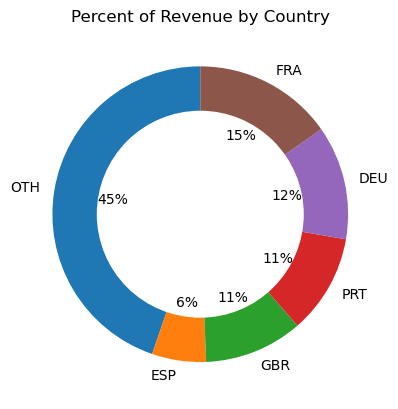

In [34]:
fig, ax = plt.subplots()

ax.pie(pie_data['LodgingRevenue'],
      startangle=90,
      labels=pie_data.index,
      autopct='%.0f%%')

hole = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(hole)

ax.set_title('Percent of Revenue by Country')

plt.show()

# Assignment 6: Scatterplots & Histograms

* Build a scatterplot comparing average nights stayed by country to average revenue per customer by country.
* Then, build a bubble chart by specifying the size of the bubbles as the average nightly revenue.
* Finally, build a histogram comparing customer age in Germany to the Customer age in france. Make sure to tweak your alpha!
<mark style="background-color: black">
    hotels.assign(total_revenue = hotels["LodgingRevenue"] + hotels["OtherRevenue"],
                      revenue_per_night = lambda x: x["total_revenue"] / x["RoomNights"])</mark>


Thanks!

In [35]:
hotels = hotels.assign(total_revenue = hotels['LodgingRevenue'] + hotels['OtherRevenue'],
                      revenue_per_night = lambda x: x['total_revenue'] / x['RoomNights'])

In [36]:
agg_hotels = hotels.groupby('Nationality').agg(
    total_revenue = ('total_revenue', 'sum'),
    avg_revenue = ('total_revenue', 'mean'),
    avg_age = ('Age', 'mean'),
    avg_nights = ('RoomNights', 'mean'),
    avg_nightly_revenue = ('revenue_per_night', 'mean')
)

Text(0.5, 0, 'Average Revenue per Customer')

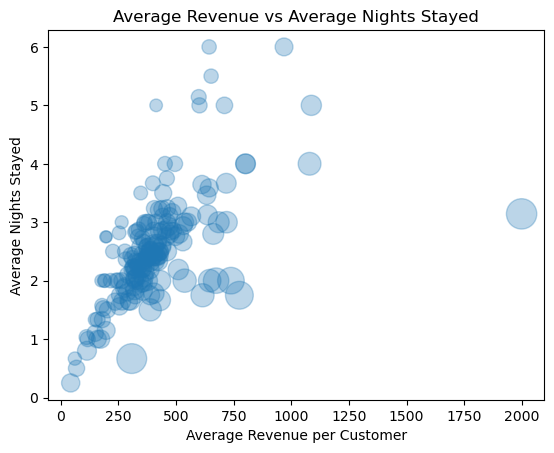

In [37]:
fig, ax = plt.subplots()

ax.scatter(
    agg_hotels['avg_revenue'],
    agg_hotels['avg_nights'],
    s=agg_hotels['avg_nightly_revenue'],
    alpha=.3
)

ax.set_title('Average Revenue vs Average Nights Stayed')
ax.set_ylabel('Average Nights Stayed')
ax.set_xlabel('Average Revenue per Customer')

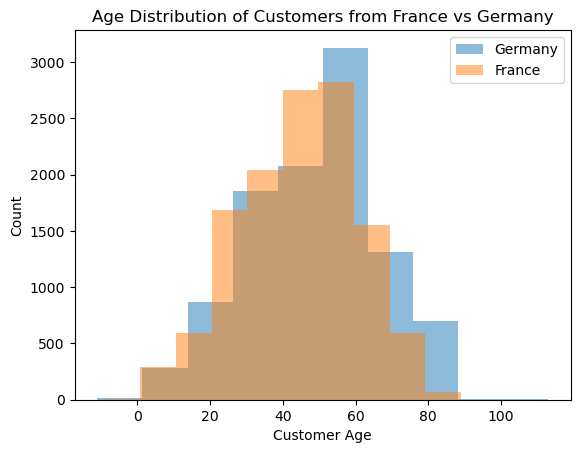

In [39]:
fig, ax = plt.subplots()

ax.hist(hotels.loc[hotels['Nationality'] == 'DEU', 'Age'], alpha=.5)
ax.hist(hotels.loc[hotels['Nationality'] == 'FRA', 'Age'], alpha=.5)

ax.set_title('Age Distribution of Customers from France vs Germany')
ax.set_xlabel('Customer Age')
ax.set_ylabel('Count')

ax.legend(['Germany', 'France'])